## Importing the packages

In [1]:
import numpy as np
import pandas as pd
!pip install seaborn
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

## Loading the dataset

In [4]:
data=pd.read_csv("diabetes.csv")

In [5]:
data

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1
...,...,...,...,...,...,...,...,...,...
763,10,101,76,48,180,32.9,0.171,63,0
764,2,122,70,27,0,36.8,0.340,27,0
765,5,121,72,23,112,26.2,0.245,30,0
766,1,126,60,0,0,30.1,0.349,47,1


In [6]:
data.shape

(768, 9)

In [8]:
data["Outcome"].value_counts()

Outcome
0    500
1    268
Name: count, dtype: int64

### Checking the data types

In [9]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [10]:
data.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


## Data pre-processing

In [13]:
new_df = data

In [14]:
new_df.isnull().sum()

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

In [15]:
new_df=new_df.dropna()
new_df

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1
...,...,...,...,...,...,...,...,...,...
763,10,101,76,48,180,32.9,0.171,63,0
764,2,122,70,27,0,36.8,0.340,27,0
765,5,121,72,23,112,26.2,0.245,30,0
766,1,126,60,0,0,30.1,0.349,47,1


In [17]:
X = new_df.drop(columns=['Outcome'],axis=1)
Y = new_df['Outcome']

In [18]:
X.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age
0,6,148,72,35,0,33.6,0.627,50
1,1,85,66,29,0,26.6,0.351,31
2,8,183,64,0,0,23.3,0.672,32
3,1,89,66,23,94,28.1,0.167,21
4,0,137,40,35,168,43.1,2.288,33


In [19]:
Y.head()

0    1
1    0
2    1
3    0
4    1
Name: Outcome, dtype: int64

In [20]:
from sklearn.model_selection import train_test_split
X_train, X_test,Y_train,Y_test = train_test_split(X,Y,stratify=Y,test_size=0.1,random_state=2)

In [21]:
X_test

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age
148,5,147,78,0,0,33.7,0.218,65
429,1,95,82,25,180,35.0,0.233,43
190,3,111,62,0,0,22.6,0.142,21
581,6,109,60,27,0,25.0,0.206,27
318,3,115,66,39,140,38.1,0.150,28
...,...,...,...,...,...,...,...,...
357,13,129,0,30,0,39.9,0.569,44
415,3,173,84,33,474,35.7,0.258,22
554,1,84,64,23,115,36.9,0.471,28
158,2,88,74,19,53,29.0,0.229,22


In [22]:
Y_test

148    0
429    1
190    0
581    0
318    0
      ..
357    1
415    1
554    0
158    0
352    0
Name: Outcome, Length: 77, dtype: int64

In [23]:
print(X.shape,X_train.shape,X_test.shape)

(768, 8) (691, 8) (77, 8)


In [24]:
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import ExtraTreesClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

In [25]:
models = [LogisticRegression(random_state = 0),KNeighborsClassifier(n_neighbors=30),ExtraTreesClassifier(n_estimators=15, random_state=42,max_features="log2"),GaussianNB(),DecisionTreeClassifier(random_state = 0),RandomForestClassifier(random_state = 0)]
models_name=["Logistic Regression","KNeighbors Classifier","ExtraTrees Classifier","GaussianNB","DecisionTree Classifier","RandomForest Classifier"]

In [26]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
score=[]
def compare_models(models):
    i=0
    for model in models:
        
        model.fit(X_train,Y_train)
        y_pred=model.predict(X_test)
       
        accuracy = accuracy_score(Y_test, y_pred)
        classification_rep = classification_report(Y_test, y_pred)
        conf_matrix = confusion_matrix(Y_test, y_pred)
        score.append(accuracy)
        
        print(f"Accuracy of {models_name[i]}")
        print(f"Accuracy: {accuracy:.4f}")
        print("\nConfusion Matrix:\n", conf_matrix)
        print("\nClassification Report:\n", classification_rep)
        print("------------------------------------------------------")
        i+=1

In [27]:
compare_models(models)

Accuracy of Logistic Regression
Accuracy: 0.7403

Confusion Matrix:
 [[43  7]
 [13 14]]

Classification Report:
               precision    recall  f1-score   support

           0       0.77      0.86      0.81        50
           1       0.67      0.52      0.58        27

    accuracy                           0.74        77
   macro avg       0.72      0.69      0.70        77
weighted avg       0.73      0.74      0.73        77

------------------------------------------------------
Accuracy of KNeighbors Classifier
Accuracy: 0.7143

Confusion Matrix:
 [[44  6]
 [16 11]]

Classification Report:
               precision    recall  f1-score   support

           0       0.73      0.88      0.80        50
           1       0.65      0.41      0.50        27

    accuracy                           0.71        77
   macro avg       0.69      0.64      0.65        77
weighted avg       0.70      0.71      0.69        77

------------------------------------------------------
Accuracy

In [28]:
score

[0.7402597402597403,
 0.7142857142857143,
 0.6883116883116883,
 0.7402597402597403,
 0.7012987012987013,
 0.7402597402597403]

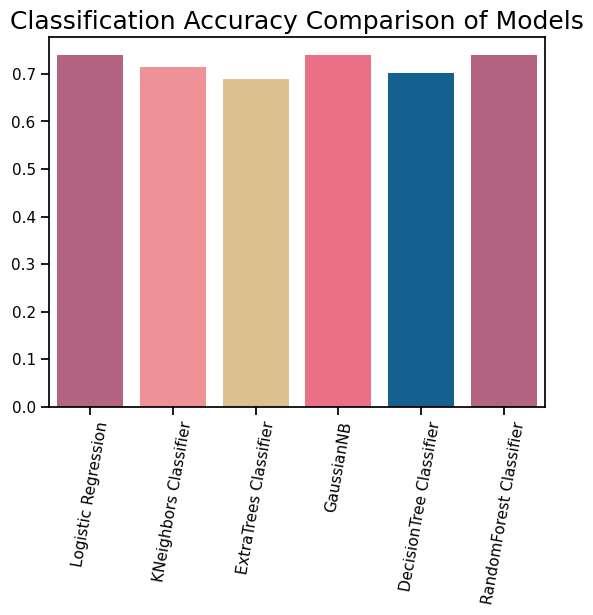

In [29]:
sns.set(context='notebook', style=None)
ax = sns.barplot(x=models_name, y=score, palette=['#C05780','#FF828B','#E7C582','#FF5C77','#0065A2'])
ax.set_title('Classification Accuracy Comparison of Models', fontsize=18)
for item in ax.get_xticklabels():
    item.set_rotation(80)
for p in ax.patches:
        ax.annotate('{:}%'.format(p.get_height()), (p.get_x()+0.01, p.get_height()+1))

In [30]:
model=RandomForestClassifier(random_state=0)

In [31]:
model.fit(X_train,Y_train)

RandomForestClassifier(random_state=0)

In [32]:
X_test

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age
148,5,147,78,0,0,33.7,0.218,65
429,1,95,82,25,180,35.0,0.233,43
190,3,111,62,0,0,22.6,0.142,21
581,6,109,60,27,0,25.0,0.206,27
318,3,115,66,39,140,38.1,0.150,28
...,...,...,...,...,...,...,...,...
357,13,129,0,30,0,39.9,0.569,44
415,3,173,84,33,474,35.7,0.258,22
554,1,84,64,23,115,36.9,0.471,28
158,2,88,74,19,53,29.0,0.229,22


In [33]:
Y_test

148    0
429    1
190    0
581    0
318    0
      ..
357    1
415    1
554    0
158    0
352    0
Name: Outcome, Length: 77, dtype: int64

In [34]:
#making a predictive system
input_data=(5,166,72,19,175,25.8,0.587,51)

#changing the input data to numpy array
input_data_as_numpy_array=np.asarray(input_data)

#reshape the array as we are predicting for one instance
input_data_reshaped=input_data_as_numpy_array.reshape(1,-1)

prediction=model.predict(input_data_reshaped)
print(prediction)

if(prediction[0]==0):
    print("The person doesn\'t suffer Diabetes.")
else:
    print("The person suffers Diabetes.")

[1]
The person suffers Diabetes.


In [35]:
#making a predictive system
input_data=(13,145,82,19,110,22.2,0.245,57)

#changing the input data to numpy array
input_data_as_numpy_array=np.asarray(input_data)

#reshape the array as we are predicting for one instance
input_data_reshaped=input_data_as_numpy_array.reshape(1,-1)

prediction=model.predict(input_data_reshaped)
print(prediction)

if(prediction[0]==0):
    print("The person doesn\'t suffer diabetes.")
else:
    print("The person suffers diabetes.")

[0]
The person doesn't suffer diabetes.


In [36]:
#making a predictive system
input_data=(0,180,66,39,0,42.0,1.893,25)

#changing the input data to numpy array
input_data_as_numpy_array=np.asarray(input_data)

#reshape the array as we are predicting for one instance
input_data_reshaped=input_data_as_numpy_array.reshape(1,-1)

prediction=model.predict(input_data_reshaped)
print(prediction)

if(prediction[0]==0):
    print("The person doesn\'t suffer diabetes")
else:
    print("The person suffers diabetes")

[1]
The person suffers diabetes


In [37]:
import pickle

In [38]:
filename='diabetes_model.pkl'
pickle.dump(model,open(filename,'wb'))

In [39]:
loaded_model=pickle.load(open("diabetes_model.pkl",'rb'))

In [40]:
#making a predictive system
input_data=(2,71,70,27,0,28.0,0.586,22)

#changing the input data to numpy array
input_data_as_numpy_array=np.asarray(input_data)

#reshape the array as we are predicting for one instance
input_data_reshaped=input_data_as_numpy_array.reshape(1,-1)

prediction=loaded_model.predict(input_data_reshaped)
print(prediction)

if(prediction[0]==0):
    print("The person doesn\'t suffer brain stroke.")
else:
    print("The person suffers brain stroke.")

[0]
The person doesn't suffer brain stroke.
